# Trader Performance vs Bitcoin Market Sentiment

This notebook combines trader data from Hyperliquid with the Bitcoin Fear and Greed Index. The goal is to see how trader activity and performance change under different sentiment conditions.

## 1. Import Libraries

In [1]:
from pathlib import Path
import os

os.environ['MPLCONFIGDIR'] = str(Path('eda_outputs') / '.mplconfig')
Path('eda_outputs').mkdir(exist_ok=True)
Path(os.environ['MPLCONFIGDIR']).mkdir(exist_ok=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

## 2. Load the Data

In [2]:
trades = pd.read_csv('historical_data.csv')
sentiment = pd.read_csv('fear_greed_index.csv')

print('Trader data rows and columns:', trades.shape)
print('Sentiment data rows and columns:', sentiment.shape)

Trader data rows and columns: (211224, 16)
Sentiment data rows and columns: (2644, 4)


In [3]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,986.87,"7,872.16",BUY,02-12-2024 22:50,0.00,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.35,"895,000,000,000,000.00","1,730,000,000,000.00"
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.98,16.00,127.68,BUY,02-12-2024 22:50,986.52,Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.01,"443,000,000,000,000.00","1,730,000,000,000.00"
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,144.09,"1,150.63",BUY,02-12-2024 22:50,"1,002.52",Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.05,"660,000,000,000,000.00","1,730,000,000,000.00"
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,142.98,"1,142.04",BUY,02-12-2024 22:50,"1,146.56",Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.05,"1,080,000,000,000,000.00","1,730,000,000,000.00"
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.99,8.73,69.75,BUY,02-12-2024 22:50,"1,289.49",Buy,0.00,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.00,"1,050,000,000,000,000.00","1,730,000,000,000.00"


In [4]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


## 3. Clean the Date Columns

In [5]:
trades['timestamp_ist_dt'] = pd.to_datetime(
    trades['Timestamp IST'],
    format='%d-%m-%Y %H:%M',
    errors='coerce'
)

trades['date'] = trades['timestamp_ist_dt'].dt.normalize()
trades['month'] = trades['timestamp_ist_dt'].dt.to_period('M').astype(str)
trades['hour'] = trades['timestamp_ist_dt'].dt.hour
trades['net_pnl'] = trades['Closed PnL'] - trades['Fee']

sentiment['date'] = pd.to_datetime(sentiment['date'], format='%Y-%m-%d', errors='coerce')
sentiment = sentiment[['date', 'value', 'classification']].copy()
sentiment = sentiment.dropna(subset=['date'])

print('Earliest trade date:', trades['date'].min())
print('Latest trade date:', trades['date'].max())
print('Earliest sentiment date:', sentiment['date'].min())
print('Latest sentiment date:', sentiment['date'].max())

Earliest trade date: 2023-05-01 00:00:00
Latest trade date: 2025-05-01 00:00:00
Earliest sentiment date: 2018-02-01 00:00:00
Latest sentiment date: 2025-05-02 00:00:00


## 4. Basic Summary Metrics

In [6]:
number_of_accounts = trades['Account'].nunique()
number_of_coins = trades['Coin'].nunique()
total_volume = trades['Size USD'].sum()
total_net_pnl = trades['net_pnl'].sum()

summary_metrics = pd.DataFrame({
    'metric': [
        'trader_rows',
        'trader_columns',
        'accounts',
        'coins',
        'trader_date_start',
        'trader_date_end',
        'sentiment_date_start',
        'sentiment_date_end',
        'gross_volume_usd',
        'total_net_pnl'
    ],
    'value': [
        len(trades),
        trades.shape[1],
        number_of_accounts,
        number_of_coins,
        trades['date'].min(),
        trades['date'].max(),
        sentiment['date'].min(),
        sentiment['date'].max(),
        total_volume,
        total_net_pnl
    ]
})

summary_metrics

,metric,value
0,trader_rows,211224
1,trader_columns,21
2,accounts,32
3,coins,246
4,trader_date_start,2023-05-01 00:00:00
5,trader_date_end,2025-05-01 00:00:00
6,sentiment_date_start,2018-02-01 00:00:00
7,sentiment_date_end,2025-05-02 00:00:00
8,gross_volume_usd,"1,191,187,442.46"
9,total_net_pnl,"10,051,101.22"


## 5. Create Daily Trader Summary

In [7]:
daily = trades.groupby('date').agg({
    'Order ID': 'count',
    'Account': 'nunique',
    'Coin': 'nunique',
    'Size USD': 'sum',
    'Closed PnL': 'sum',
    'Fee': 'sum',
    'net_pnl': 'sum'
}).reset_index()

daily = daily.rename(columns={
    'Order ID': 'trades',
    'Account': 'accounts',
    'Coin': 'coins',
    'Size USD': 'volume_usd',
    'Closed PnL': 'gross_pnl',
    'Fee': 'fees'
})

win_rate_table = trades.groupby('date')['Closed PnL'].apply(lambda x: (x > 0).mean()).reset_index()
win_rate_table = win_rate_table.rename(columns={'Closed PnL': 'win_rate'})

daily = daily.merge(win_rate_table, on='date', how='left')

daily.head()

,date,trades,accounts,coins,volume_usd,gross_pnl,fees,net_pnl,win_rate
0,2023-05-01,3,1,1,477.00,0.00,0.00,0.00,0.00
1,2023-12-05,9,1,2,"50,005.83",0.00,12.50,-12.50,0.00
2,2023-12-14,11,1,4,"113,203.35",-205.43,28.30,-233.74,0.36
3,2023-12-15,2,1,1,"10,609.95",-24.63,2.65,-27.28,0.00
4,2023-12-16,3,1,1,"15,348.77",0.00,3.84,-3.84,0.00


## 6. Merge Daily Trader Data with Sentiment Data

In [8]:
daily_sentiment = pd.merge(daily, sentiment, on='date', how='left')

daily_sentiment['sentiment_bucket'] = pd.qcut(
    daily_sentiment['value'],
    q=4,
    duplicates='drop'
)

print('Number of daily rows:', len(daily_sentiment))
print('Missing sentiment classifications:', daily_sentiment['classification'].isna().sum())

daily_sentiment.head()

Number of daily rows: 480
Missing sentiment classifications: 1


,date,trades,accounts,coins,volume_usd,gross_pnl,fees,net_pnl,win_rate,value,classification,sentiment_bucket
0,2023-05-01,3,1,1,477.00,0.00,0.00,0.00,0.00,63.00,Greed,"(48.0, 67.0]"
1,2023-12-05,9,1,2,"50,005.83",0.00,12.50,-12.50,0.00,75.00,Extreme Greed,"(74.0, 94.0]"
2,2023-12-14,11,1,4,"113,203.35",-205.43,28.30,-233.74,0.36,72.00,Greed,"(67.0, 74.0]"
3,2023-12-15,2,1,1,"10,609.95",-24.63,2.65,-27.28,0.00,70.00,Greed,"(67.0, 74.0]"
4,2023-12-16,3,1,1,"15,348.77",0.00,3.84,-3.84,0.00,67.00,Greed,"(48.0, 67.0]"


## 7. Sentiment Regime Summary

In [9]:
regime_summary = daily_sentiment.groupby('classification').agg({
    'date': 'count',
    'trades': 'mean',
    'accounts': 'mean',
    'coins': 'mean',
    'volume_usd': 'mean',
    'net_pnl': ['sum', 'mean', 'median'],
    'win_rate': 'mean'
})

regime_summary.columns = [
    'days',
    'avg_trades',
    'avg_accounts',
    'avg_coins',
    'avg_volume_usd',
    'total_net_pnl',
    'avg_net_pnl',
    'median_net_pnl',
    'avg_win_rate'
]

regime_summary = regime_summary.reset_index()
regime_summary = regime_summary.sort_values('avg_net_pnl', ascending=False)

regime_summary

,classification,days,avg_trades,avg_accounts,avg_coins,avg_volume_usd,total_net_pnl,avg_net_pnl,median_net_pnl,avg_win_rate
0,Extreme Fear,14,"1,528.57",11.43,19.36,"8,177,447.25","715,221.61","51,087.26","21,159.93",0.33
2,Fear,91,679.53,6.92,10.38,"5,311,261.43","3,264,698.49","35,875.81","1,308.45",0.33
1,Extreme Greed,114,350.81,4.61,12.97,"1,091,799.69","2,688,140.65","23,580.18","3,050.36",0.47
4,Neutral,67,562.48,5.61,11.61,"2,690,180.05","1,253,546.41","18,709.65","1,565.09",0.33
3,Greed,193,260.64,3.36,8.28,"1,495,246.09","2,087,030.58","10,813.63",608.26,0.34


## 8. Sentiment Quartile Summary

In [10]:
quartile_summary = daily_sentiment.groupby('sentiment_bucket', observed=False).agg({
    'date': 'count',
    'net_pnl': 'mean',
    'volume_usd': 'mean',
    'win_rate': 'mean'
}).reset_index()

quartile_summary = quartile_summary.rename(columns={
    'date': 'days',
    'net_pnl': 'avg_net_pnl',
    'volume_usd': 'avg_volume_usd',
    'win_rate': 'avg_win_rate'
})

quartile_summary

,sentiment_bucket,days,avg_net_pnl,avg_volume_usd,avg_win_rate
0,"(9.999, 48.0]",125,"38,505.66","5,495,169.49",0.33
1,"(48.0, 67.0]",115,"8,779.97","2,227,884.15",0.29
2,"(67.0, 74.0]",125,"11,980.74","988,245.96",0.37
3,"(74.0, 94.0]",114,"23,580.18","1,091,799.69",0.47


## 9. Correlation Between Sentiment and Performance

In [11]:
correlation_net_pnl = daily_sentiment['value'].corr(daily_sentiment['net_pnl'])
correlation_volume = daily_sentiment['value'].corr(daily_sentiment['volume_usd'])
correlation_trades = daily_sentiment['value'].corr(daily_sentiment['trades'])
correlation_win_rate = daily_sentiment['value'].corr(daily_sentiment['win_rate'])

corr_summary = pd.DataFrame({
    'metric': [
        'sentiment_value_vs_daily_net_pnl',
        'sentiment_value_vs_daily_volume',
        'sentiment_value_vs_daily_trades',
        'sentiment_value_vs_daily_win_rate'
    ],
    'correlation': [
        correlation_net_pnl,
        correlation_volume,
        correlation_trades,
        correlation_win_rate
    ]
})

corr_summary

,metric,correlation
0,sentiment_value_vs_daily_net_pnl,-0.08
1,sentiment_value_vs_daily_volume,-0.26
2,sentiment_value_vs_daily_trades,-0.25
3,sentiment_value_vs_daily_win_rate,0.15


## 10. Account-Day Performance by Sentiment

In [12]:
account_day = trades.groupby(['date', 'Account']).agg({
    'Order ID': 'count',
    'Size USD': 'sum',
    'net_pnl': 'sum'
}).reset_index()

account_day = account_day.rename(columns={
    'Order ID': 'trades',
    'Size USD': 'volume_usd'
})

account_day = account_day.merge(sentiment, on='date', how='left')

account_day_summary = account_day.groupby('classification').agg({
    'Account': 'count',
    'net_pnl': ['mean', 'median'],
})

account_day_summary.columns = ['account_day_obs', 'avg_account_day_pnl', 'median_account_day_pnl']
account_day_summary = account_day_summary.reset_index()

profitable_share = account_day.groupby('classification')['net_pnl'].apply(lambda x: (x > 0).mean()).reset_index()
profitable_share = profitable_share.rename(columns={'net_pnl': 'profitable_share'})

account_day_summary = account_day_summary.merge(profitable_share, on='classification', how='left')
account_day_summary = account_day_summary[['classification', 'account_day_obs', 'profitable_share', 'avg_account_day_pnl', 'median_account_day_pnl']]
account_day_summary = account_day_summary.sort_values('avg_account_day_pnl', ascending=False)

account_day_summary

,classification,account_day_obs,profitable_share,avg_account_day_pnl,median_account_day_pnl
2,Fear,630,0.60,"5,182.06",97.09
1,Extreme Greed,526,0.68,"5,110.53",362.83
0,Extreme Fear,160,0.58,"4,470.14",162.64
4,Neutral,376,0.62,"3,333.90",151.37
3,Greed,648,0.60,"3,220.73",140.23


## 11. Coin-Day Performance by Sentiment

In [13]:
coin_day = trades.groupby(['date', 'Coin']).agg({
    'Order ID': 'count',
    'Size USD': 'sum',
    'net_pnl': 'sum'
}).reset_index()

coin_day = coin_day.rename(columns={
    'Order ID': 'trades',
    'Size USD': 'volume_usd'
})

coin_day = coin_day.merge(sentiment, on='date', how='left')

coin_day_summary = coin_day.groupby('classification').agg({
    'Coin': 'count',
    'net_pnl': 'mean'
}).reset_index()

coin_day_summary = coin_day_summary.rename(columns={
    'Coin': 'coin_day_obs',
    'net_pnl': 'avg_coin_day_pnl'
})

coin_profitable_share = coin_day.groupby('classification')['net_pnl'].apply(lambda x: (x > 0).mean()).reset_index()
coin_profitable_share = coin_profitable_share.rename(columns={'net_pnl': 'profitable_share'})

coin_day_summary = coin_day_summary.merge(coin_profitable_share, on='classification', how='left')
coin_day_summary = coin_day_summary[['classification', 'coin_day_obs', 'profitable_share', 'avg_coin_day_pnl']]
coin_day_summary = coin_day_summary.sort_values('avg_coin_day_pnl', ascending=False)

coin_day_summary

,classification,coin_day_obs,profitable_share,avg_coin_day_pnl
2,Fear,945,0.57,"3,454.71"
0,Extreme Fear,271,0.44,"2,639.19"
1,Extreme Greed,1479,0.70,"1,817.54"
4,Neutral,778,0.58,"1,611.24"
3,Greed,1599,0.54,"1,305.21"


## 12. Top Accounts and Coins

In [14]:
account_summary = trades.groupby('Account').agg({
    'Order ID': 'count',
    'Size USD': 'sum',
    'net_pnl': 'sum'
}).reset_index()

account_summary = account_summary.rename(columns={
    'Order ID': 'trades',
    'Size USD': 'volume_usd'
})

account_summary = account_summary.sort_values('net_pnl', ascending=False)
account_summary.head(10)

,Account,trades,volume_usd,net_pnl
27,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,14733,"56,543,565.23","2,127,387.28"
0,0x083384f897ee0f19899168e3b1bec365f52a9012,3818,"61,697,263.97","1,592,824.51"
29,0xbaaaf6571ab7d571043ff1e313a9609a10637864,21192,"68,036,340.24","931,567.10"
31,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,40184,"74,107,810.44","822,727.65"
13,0x513b8629fe877bb581bf244e326a047b249c4ff1,12236,"420,876,556.36","763,997.91"
11,0x4acb90e786d897ecffb614dc822eb231b4ffb9f4,4356,"39,572,949.25","669,721.06"
15,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,1590,"11,474,500.92","427,804.13"
9,0x430f09841d65beb3f27765503d0f850b8bce7713,1237,"2,966,109.22","415,794.87"
16,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,1430,"3,051,144.33","402,721.49"
17,0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,9893,"25,729,497.24","376,500.15"


In [15]:
coin_summary = trades.groupby('Coin').agg({
    'Order ID': 'count',
    'Size USD': 'sum',
    'net_pnl': 'sum'
}).reset_index()

coin_summary = coin_summary.rename(columns={
    'Order ID': 'trades',
    'Size USD': 'volume_usd'
})

coin_summary = coin_summary.sort_values('net_pnl', ascending=False)
coin_summary.head(10)

,Coin,trades,volume_usd,net_pnl
4,@107,29992,"55,760,858.63","2,777,959.69"
137,HYPE,68005,"141,990,206.05","1,923,122.67"
205,SOL,10691,"125,074,752.06","1,611,599.62"
120,ETH,11158,"118,280,994.07","1,296,887.54"
105,BTC,26064,"644,232,116.63","728,820.51"
161,MELANIA,4428,"7,040,710.45","389,340.68"
117,ENA,990,"1,625,400.50","217,053.08"
210,SUI,1979,"7,781,167.59","197,265.63"
240,ZRO,1239,"1,213,825.42","183,543.71"
112,DOGE,826,"2,452,103.46","147,020.93"


## 13. Visuals

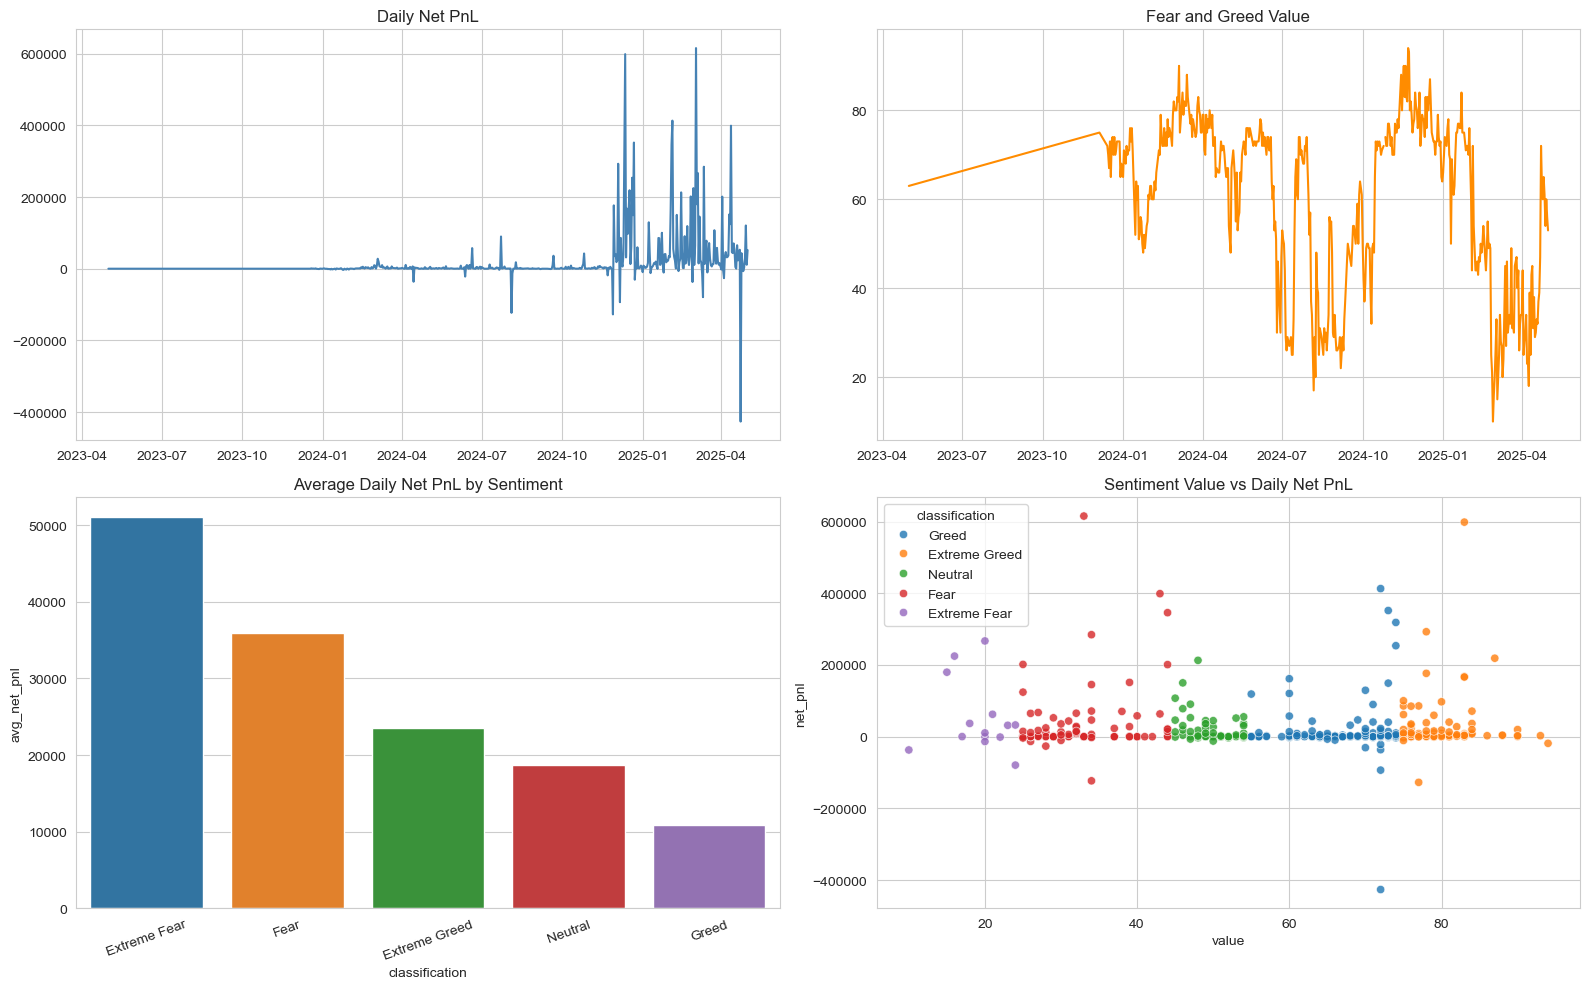

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].plot(daily_sentiment['date'], daily_sentiment['net_pnl'], color='steelblue')
axes[0, 0].set_title('Daily Net PnL')

axes[0, 1].plot(daily_sentiment['date'], daily_sentiment['value'], color='darkorange')
axes[0, 1].set_title('Fear and Greed Value')

clean_regime_summary = regime_summary.dropna(subset=['classification'])
sns.barplot(data=clean_regime_summary, x='classification', y='avg_net_pnl', hue='classification', dodge=False, legend=False, ax=axes[1, 0])
axes[1, 0].set_title('Average Daily Net PnL by Sentiment')
axes[1, 0].tick_params(axis='x', rotation=20)

plot_data = daily_sentiment.dropna(subset=['value'])
sns.scatterplot(data=plot_data, x='value', y='net_pnl', hue='classification', alpha=0.8, ax=axes[1, 1])
axes[1, 1].set_title('Sentiment Value vs Daily Net PnL')

plt.tight_layout()
plt.show()

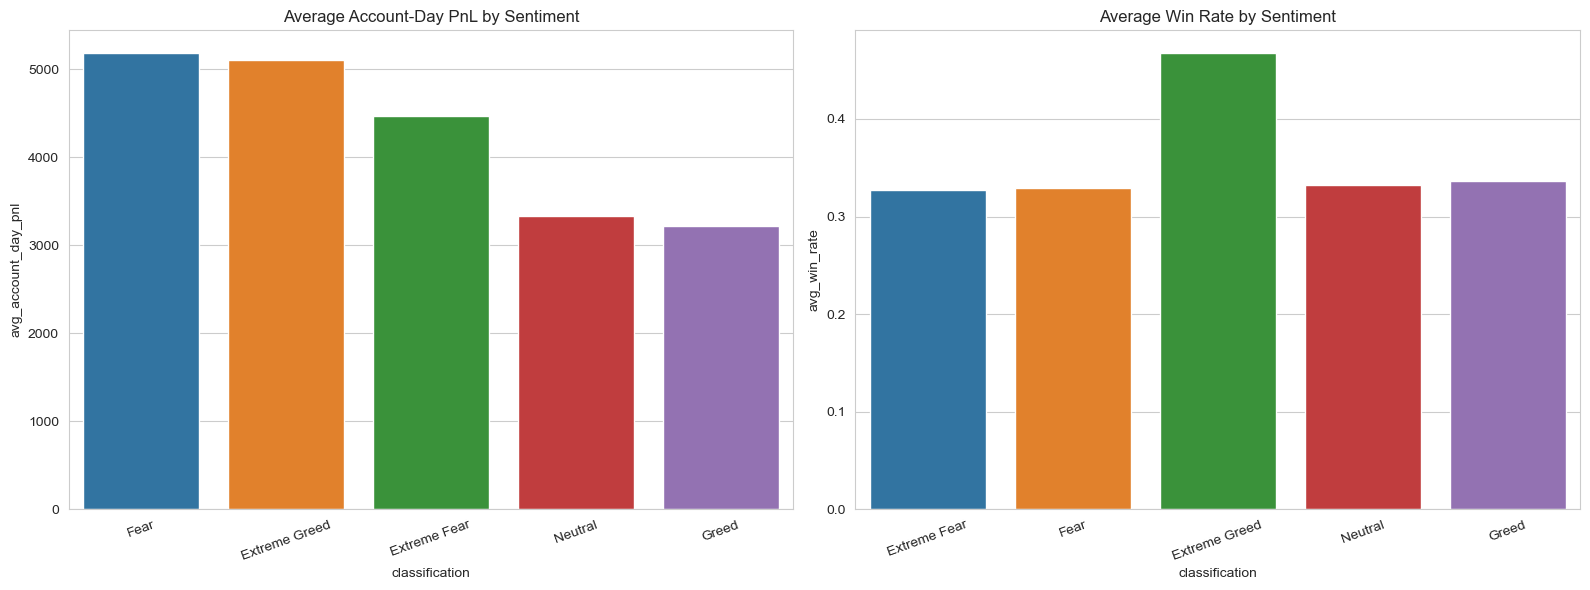

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

account_plot_data = account_day_summary.dropna(subset=['classification'])
sns.barplot(data=account_plot_data, x='classification', y='avg_account_day_pnl', hue='classification', dodge=False, legend=False, ax=axes[0])
axes[0].set_title('Average Account-Day PnL by Sentiment')
axes[0].tick_params(axis='x', rotation=20)

win_rate_plot_data = regime_summary.dropna(subset=['classification'])
sns.barplot(data=win_rate_plot_data, x='classification', y='avg_win_rate', hue='classification', dodge=False, legend=False, ax=axes[1])
axes[1].set_title('Average Win Rate by Sentiment')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 14. Final Insights

- Lower sentiment periods show higher average daily PnL and higher market activity.
- Extreme fear creates larger opportunity days, but extreme greed shows better win rate.
- Traders appear to participate more when sentiment is weak.
- This suggests strategy rules can be adjusted based on sentiment regime.